# EDA — Distribusi Transaksi Harian & Mingguan per Kategori per User

Analisis distribusi:
1. **Nominal transaksi harian** per kategori (aggregat seluruh user)
2. **Jumlah transaksi per minggu** per kategori per user

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

DATA_DIR = '../../../data/ae_10pct'

df_trx = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_nas = pd.read_csv(f'{DATA_DIR}/df_nasabah.csv')

print(f'Transaksi : {df_trx.shape}')
print(f'Nasabah   : {df_nas.shape}')
df_trx.head(3)

Transaksi : (270657, 19)
Nasabah   : (500, 14)


,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,kategori_besar,kategori_detail,label_anomali,gt_kategori_besar,gt_kategori_detail,phase,hour,hour_sin,hour_cos,kategori_detail_encoded
0,TRX-15383,USR-414,2026-01-01 00:07:00,Debit,INDOMIE REBUS WARUNG,-,5814,"8,114.1","13,355,028.6",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong,train,0,0.0,1.0,1.0
1,TRX-13457,USR-178,2026-01-01 00:22:00,Debit,KOPI KENANGAN,-,5814,"36,451.2","1,697,548.8",Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong,train,0,0.0,1.0,1.0
2,TRX-13870,USR-180,2026-01-01 00:22:00,Debit,WARTEG,-,5812,"18,616.2","2,691,817.0",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong,train,0,0.0,1.0,1.0


In [15]:
df = df_trx.copy()

df['tanggal']    = df['timestamp'].dt.date
df['minggu_num'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['hari_nama']  = df['timestamp'].dt.day_name()

df = df.dropna(subset=['kategori_detail', 'kategori_besar'])
df_debit = df[df['tipe_mutasi'] == 'Debit'].copy()

KATEGORI_ORDER = sorted(df['kategori_detail'].unique())
print('Kategori Detail:', KATEGORI_ORDER)
print('Rentang tanggal:', df['tanggal'].min(), '-', df['tanggal'].max())

Kategori Detail: ['Belanja Online & Fashion', 'F&B dan Nongkrong', 'Groceries & Kebutuhan Pokok', 'Hiburan & Langganan', 'Investasi & Finansial', 'Kesehatan & Perawatan Diri', 'Pemasukan Tambahan', 'Pendapatan Bulanan', 'Produktivitas & Digital', 'Tagihan & Utilitas', 'Transfer P2P', 'Transportasi']
Rentang tanggal: 2026-01-01 - 2026-06-29


---
## 1. Distribusi Nominal Harian per Kategori (seluruh user)

Setiap titik = total nominal transaksi satu user dalam satu hari untuk satu kategori (Debit).

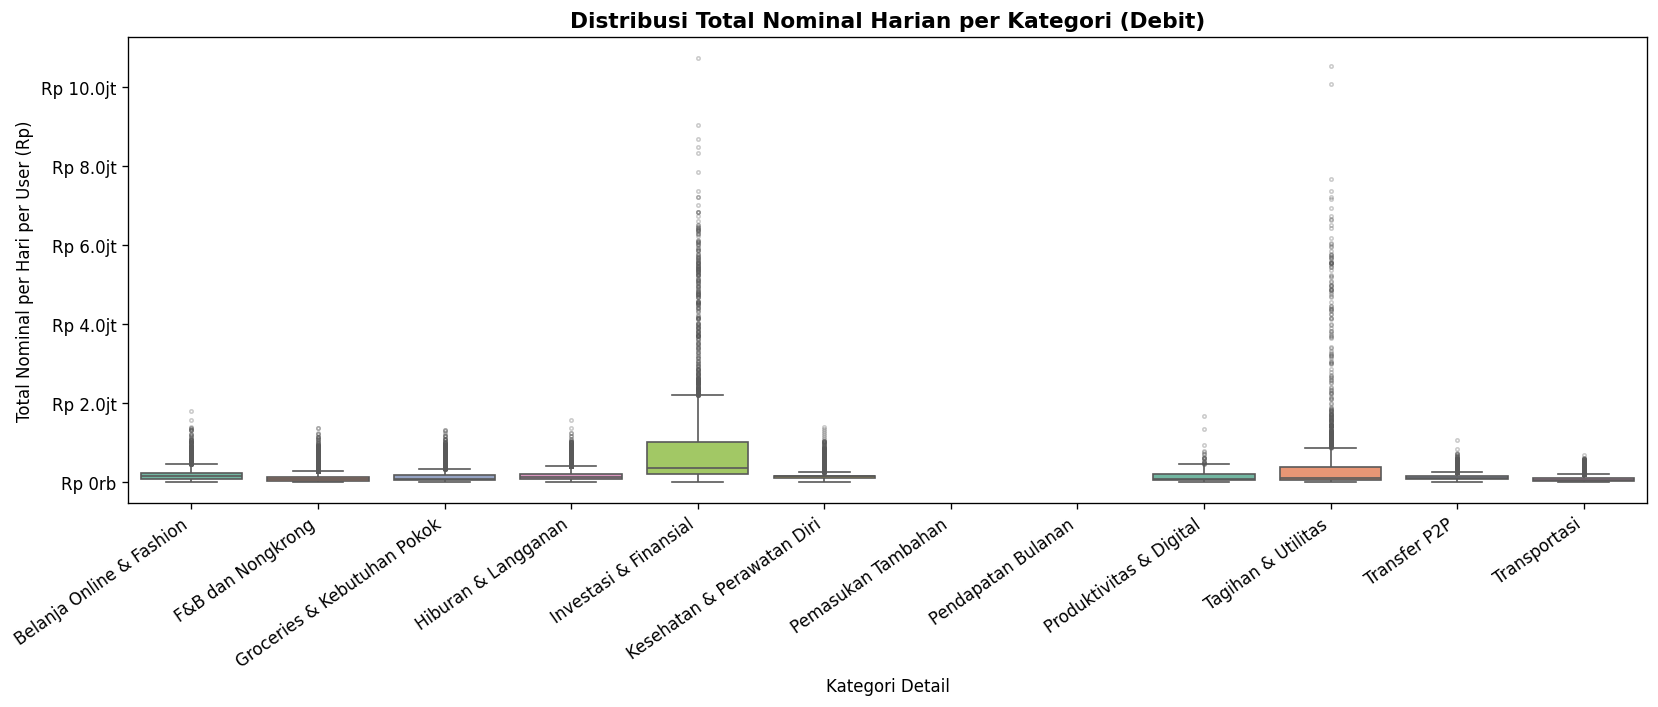


Statistik Nominal Harian per Kategori (Debit):


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"6,335.0","175,223.0","164,605.0","2,000.0","67,614.0","133,829.0","222,697.0","488,092.0","1,792,493.0"
F&B dan Nongkrong,"40,041.0","99,537.0","109,140.0","2,000.0","29,122.0","65,277.0","127,276.0","314,161.0","1,359,374.0"
Groceries & Kebutuhan Pokok,"25,748.0","121,005.0","130,096.0","2,000.0","38,817.0","74,728.0","156,511.0","384,671.0","1,308,916.0"
Hiburan & Langganan,"15,142.0","156,213.0","137,750.0","2,000.0","58,783.0","114,878.0","191,904.0","429,845.0","1,558,464.0"
Investasi & Finansial,"3,987.0","823,346.0","1,174,690.0",408.0,"203,301.0","338,000.0","999,820.0","3,284,402.0","10,737,358.0"
Kesehatan & Perawatan Diri,"6,751.0","155,275.0","131,871.0","2,000.0","81,142.0","150,000.0","150,000.0","405,070.0","1,394,940.0"
Produktivitas & Digital,"2,325.0","108,578.0","113,638.0","2,000.0","33,012.0","70,000.0","200,000.0","285,493.0","1,677,234.0"
Tagihan & Utilitas,"1,920.0","513,837.0","1,133,541.0","2,000.0","38,579.0","96,860.0","369,118.0","2,636,563.0","10,537,482.0"
Transfer P2P,"10,924.0","105,684.0","79,366.0","2,000.0","55,471.0","84,335.0","131,438.0","258,446.0","1,064,256.0"


In [16]:
daily_user_kat = (
    df_debit
    .groupby(['id_user', 'tanggal', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=daily_user_kat,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Set2',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Total Nominal Harian per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Hari per User (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Nominal Harian per Kategori (Debit):')
daily_user_kat.groupby('kategori_detail')['total_nominal'].describe(
    percentiles=[.25, .5, .75, .95]
).round(0)

---
## 2. Rata-rata Nominal Harian per Kategori — per Hari dalam Seminggu

Heatmap pola pengeluaran berdasarkan hari (Senin–Minggu).

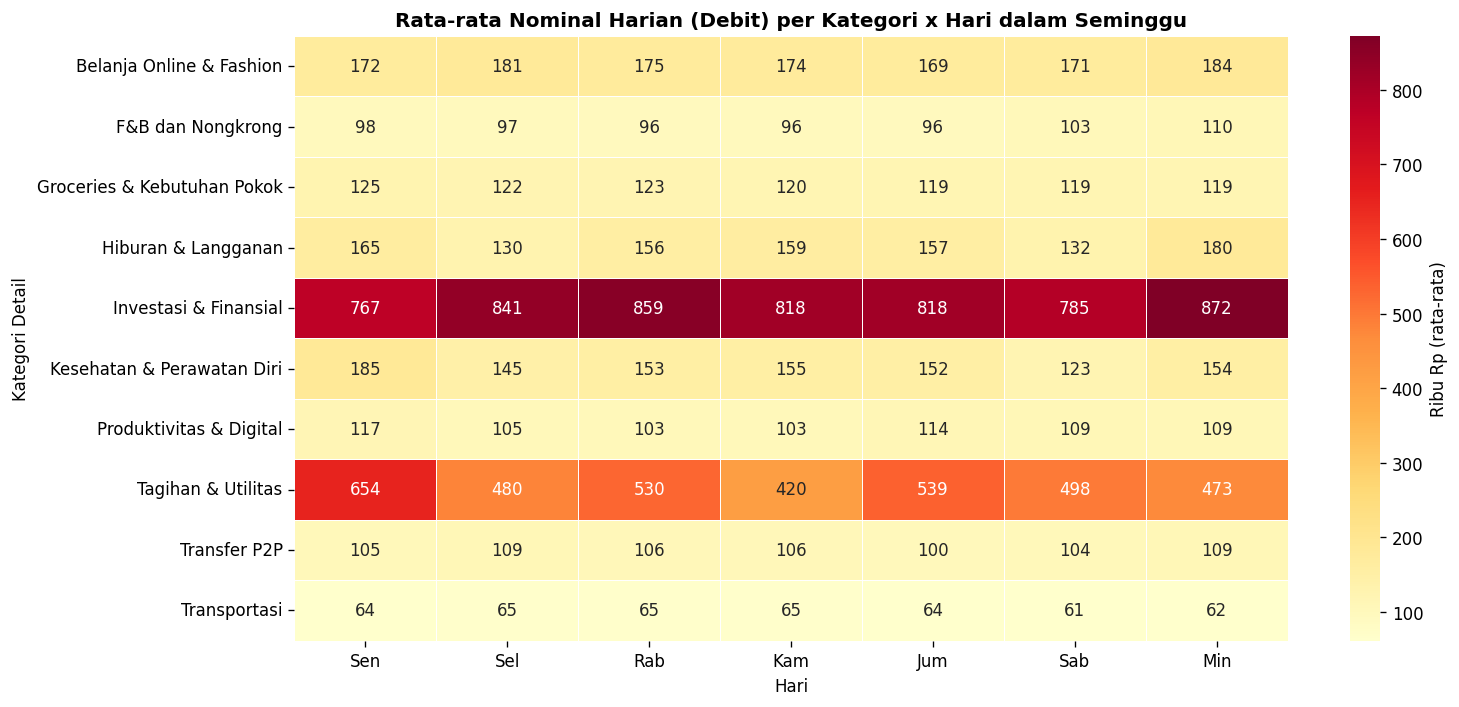

In [17]:
daily_user_kat['hari_nama'] = pd.to_datetime(daily_user_kat['tanggal']).dt.day_name()

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_LABEL = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

pivot_harian = (
    daily_user_kat
    .groupby(['kategori_detail', 'hari_nama'])['total_nominal']
    .mean()
    .unstack('hari_nama')
    .reindex(columns=DAY_ORDER)
)
pivot_harian.columns = DAY_LABEL

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_harian / 1e3,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Ribu Rp (rata-rata)'},
    ax=ax
)
ax.set_title('Rata-rata Nominal Harian (Debit) per Kategori x Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 3. Distribusi Jumlah Transaksi per Minggu per Kategori per User

Setiap titik = jumlah transaksi satu user dalam satu minggu untuk satu kategori.

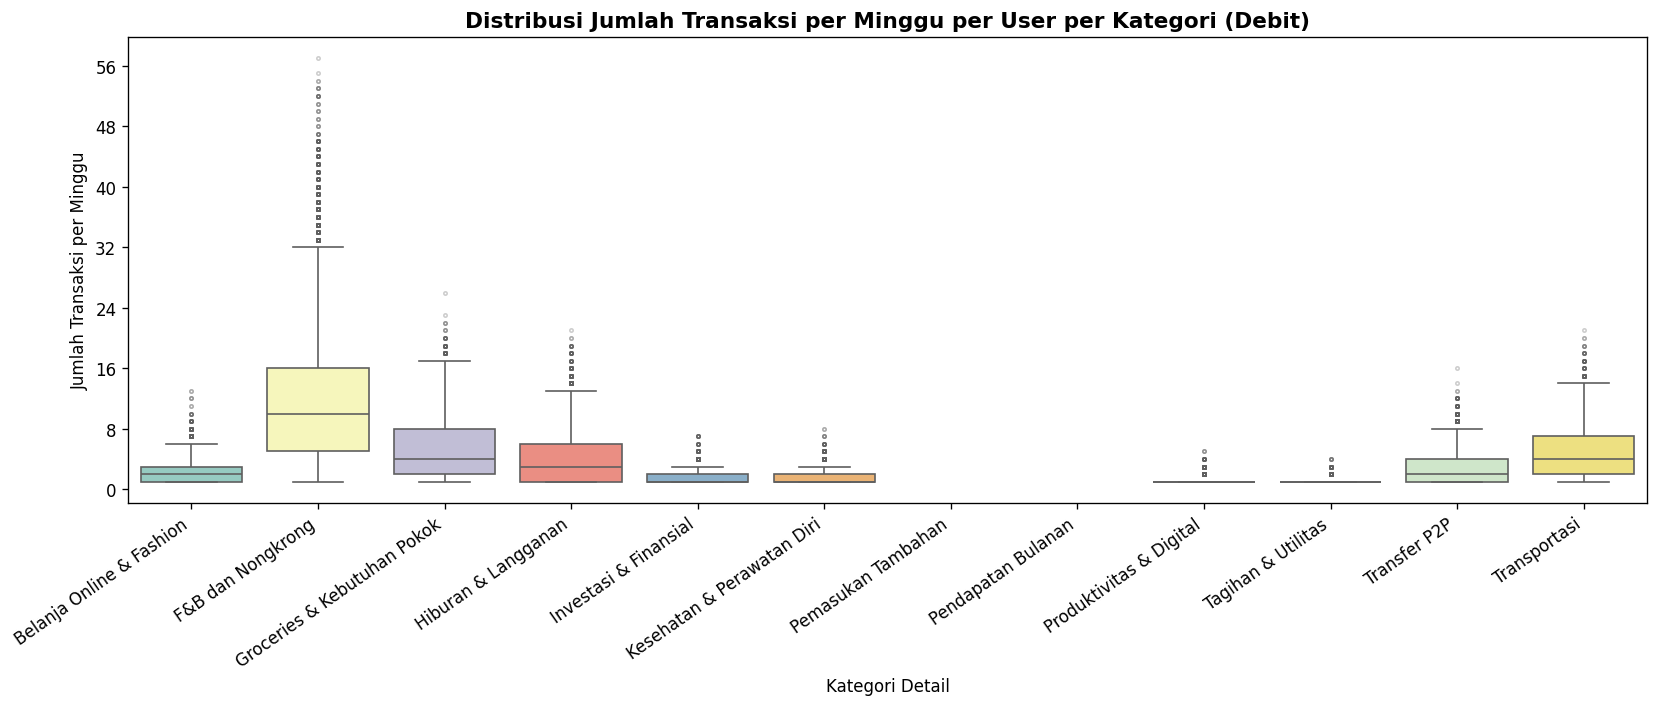


Statistik Jumlah Transaksi per Minggu per Kategori:


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"3,452.0",2.3,1.8,1.0,1.0,2.0,3.0,6.0,13.0
F&B dan Nongkrong,"9,671.0",11.8,9.5,1.0,5.0,10.0,16.0,33.0,57.0
Groceries & Kebutuhan Pokok,"8,320.0",5.2,4.1,1.0,2.0,4.0,8.0,14.0,26.0
Hiburan & Langganan,"6,293.0",4.1,3.6,1.0,1.0,3.0,6.0,12.0,21.0
Investasi & Finansial,"2,932.0",1.5,0.9,1.0,1.0,1.0,2.0,3.0,7.0
Kesehatan & Perawatan Diri,"4,907.0",1.5,0.9,1.0,1.0,1.0,2.0,3.0,8.0
Produktivitas & Digital,"1,906.0",1.3,0.6,1.0,1.0,1.0,1.0,2.0,5.0
Tagihan & Utilitas,"1,673.0",1.2,0.5,1.0,1.0,1.0,1.0,2.0,4.0
Transfer P2P,"5,060.0",2.9,2.2,1.0,1.0,2.0,4.0,8.0,16.0


In [ ]:
weekly_user_kat = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['id_transaksi']
    .count()
    .reset_index(name='jumlah_trx')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=weekly_user_kat,
    x='kategori_detail',
    y='jumlah_trx',
    order=KATEGORI_ORDER,
    palette='Set3',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Jumlah Transaksi per Minggu per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Jumlah Transaksi per Minggu')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Jumlah Transaksi per Minggu per Kategori:')
weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].describe(
    percentiles=[.25, .5, .75, .95]
).round(2)

---
## 4. Heatmap — Rata-rata Jumlah Transaksi per Minggu (Kategori x Minggu ke-N)

Tren mingguan masing-masing kategori sepanjang 3 bulan data.

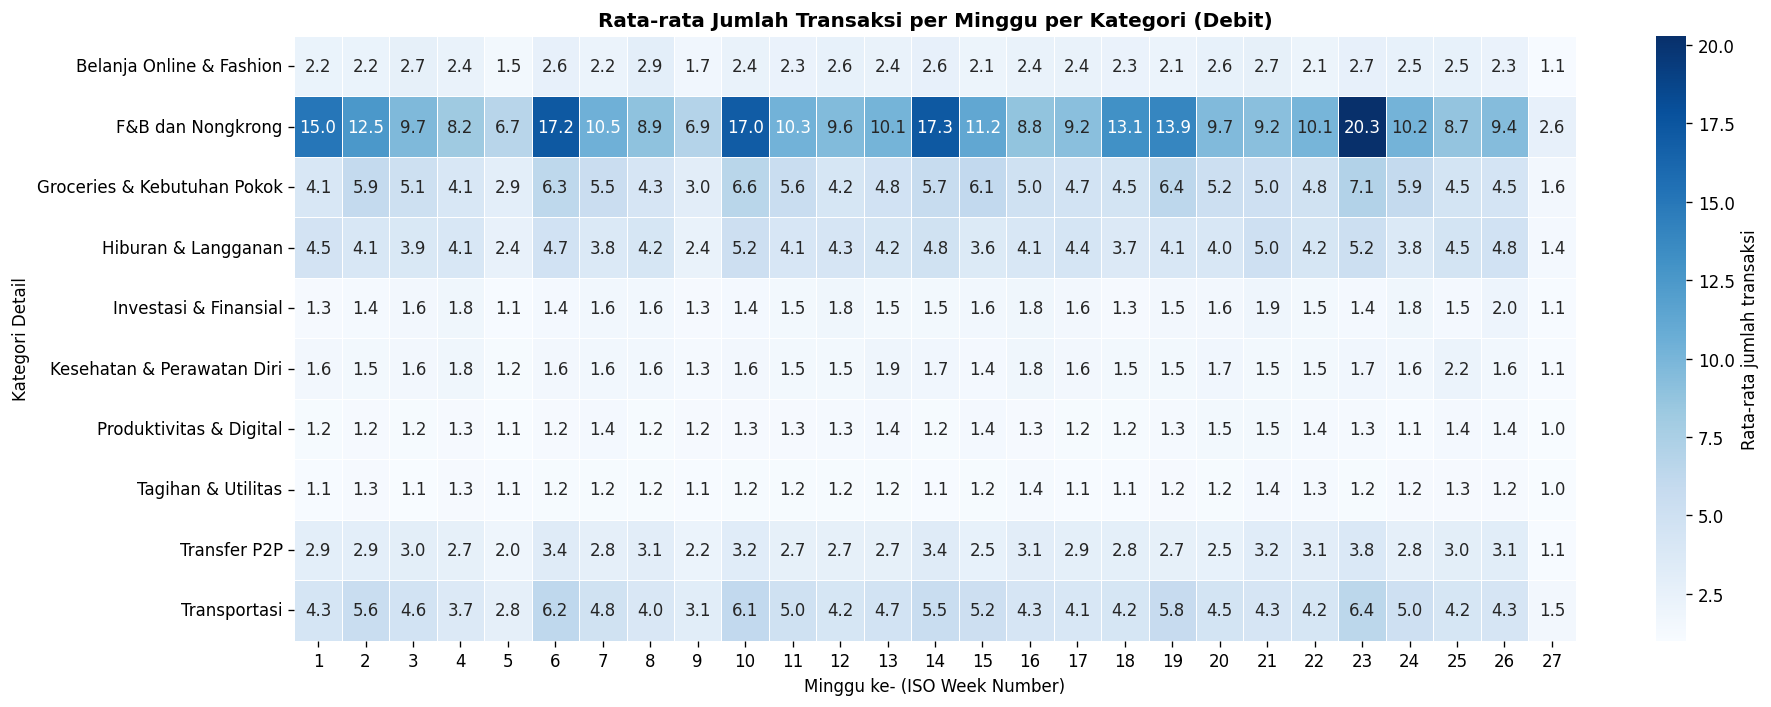

In [19]:
pivot_weekly = (
    weekly_user_kat
    .groupby(['kategori_detail', 'minggu_num'])['jumlah_trx']
    .mean()
    .unstack('minggu_num')
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_weekly,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Rata-rata jumlah transaksi'},
    ax=ax
)
ax.set_title('Rata-rata Jumlah Transaksi per Minggu per Kategori (Debit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 5. Nominal Mingguan per Kategori — Tren & Distribusi Antar-User

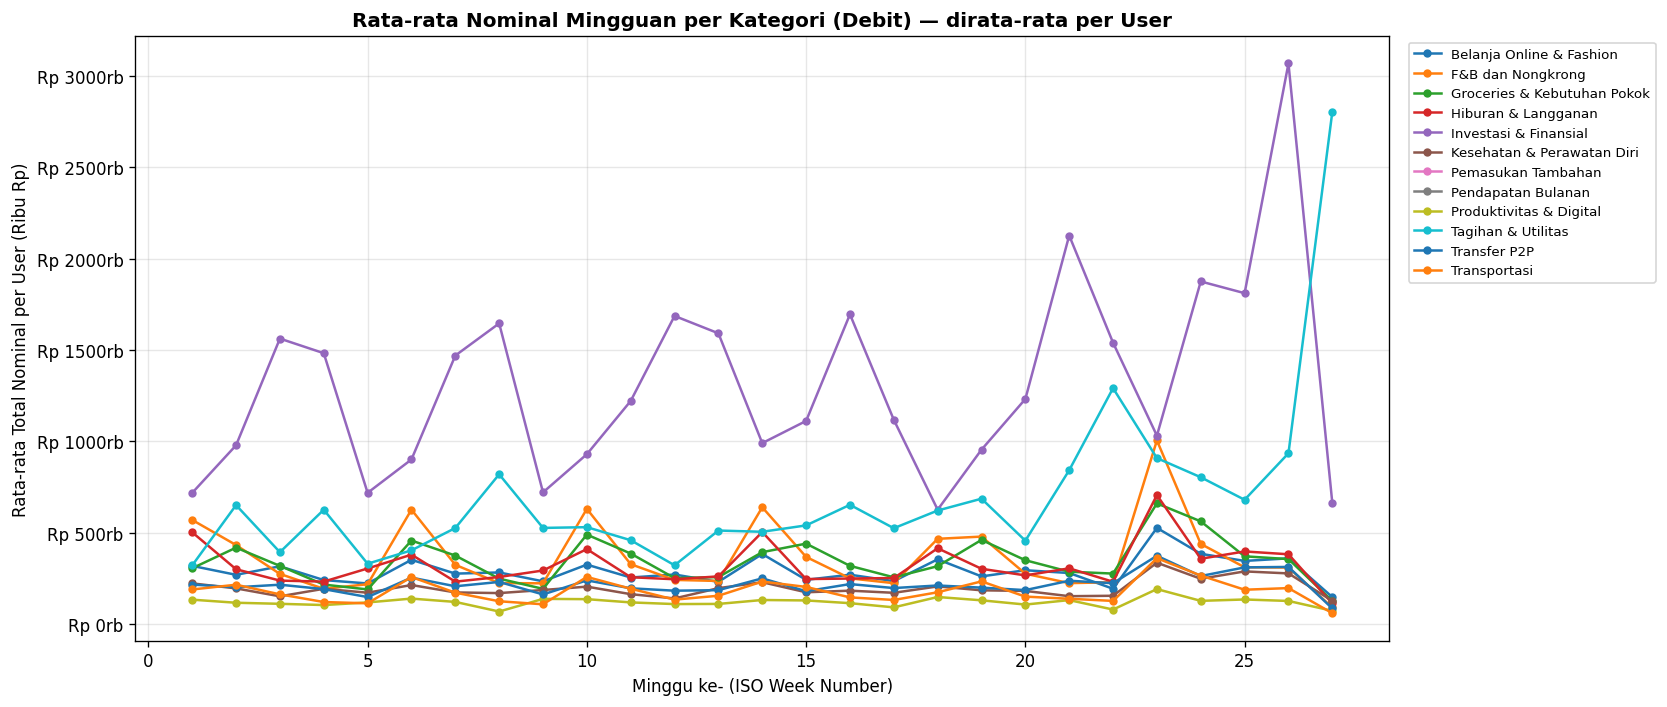

In [20]:
weekly_nominal = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

agg_weekly = (
    weekly_nominal
    .groupby(['minggu_num', 'kategori_detail'])['total_nominal']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', n_colors=len(KATEGORI_ORDER))
for i, kat in enumerate(KATEGORI_ORDER):
    subset = agg_weekly[agg_weekly['kategori_detail'] == kat]
    ax.plot(subset['minggu_num'], subset['total_nominal'] / 1e3,
            marker='o', markersize=4, label=kat, color=palette[i])

ax.set_title('Rata-rata Nominal Mingguan per Kategori (Debit) — dirata-rata per User', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Rata-rata Total Nominal per User (Ribu Rp)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

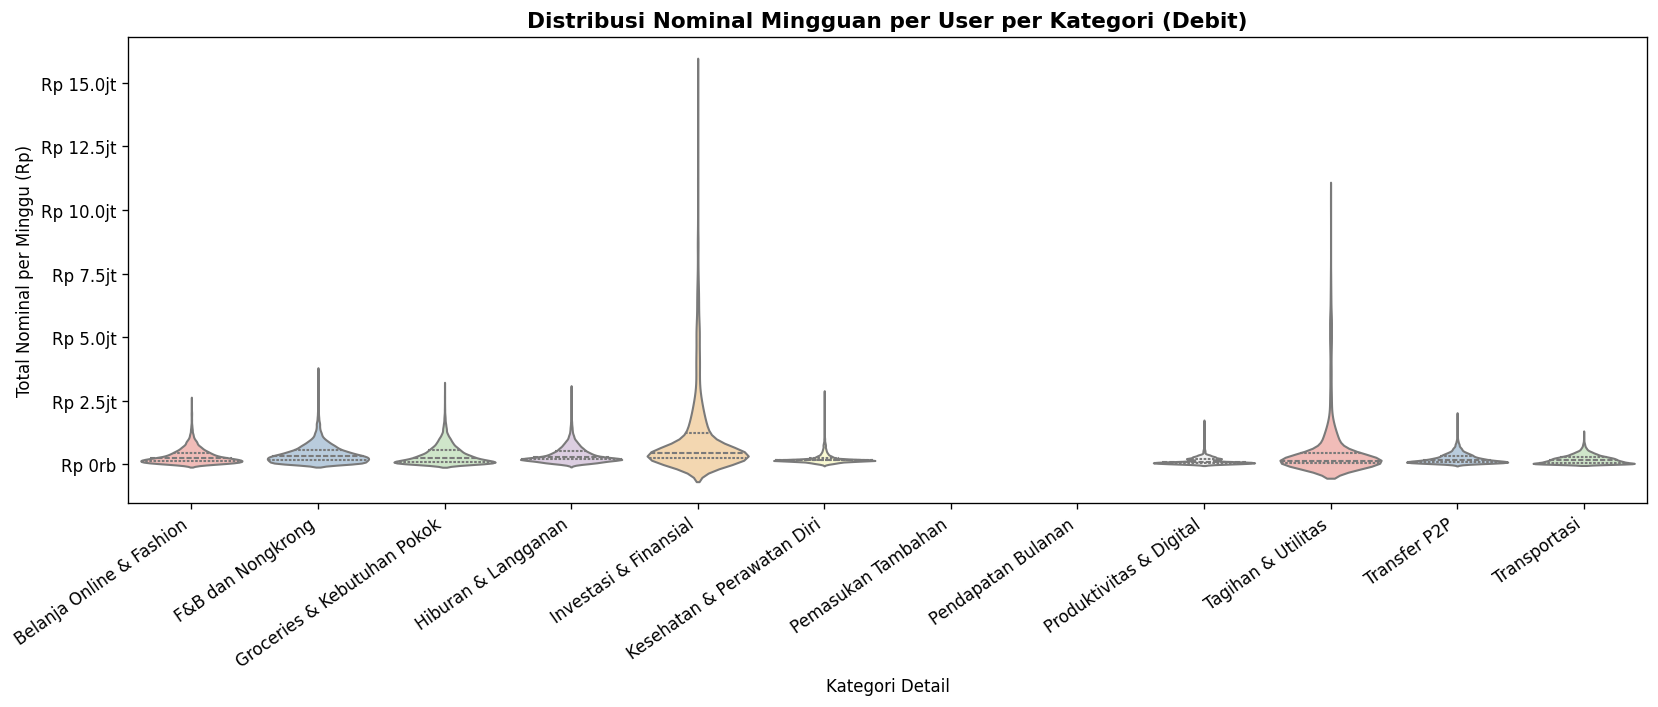

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=weekly_nominal,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribusi Nominal Mingguan per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Minggu (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Rangkuman — Tabel Statistik Mingguan per Kategori

In [22]:
summary_nominal = weekly_nominal.groupby('kategori_detail')['total_nominal'].agg(
    median_nominal = 'median',
    mean_nominal   = 'mean',
    p75_nominal    = lambda x: x.quantile(0.75),
    p95_nominal    = lambda x: x.quantile(0.95),
)

summary_trx = weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].agg(
    median_trx = 'median',
    mean_trx   = 'mean',
    p75_trx    = lambda x: x.quantile(0.75),
    p95_trx    = lambda x: x.quantile(0.95),
)

summary = summary_nominal.join(summary_trx).round(1)
summary.columns = [
    'Median Nominal/Minggu', 'Mean Nominal/Minggu', 'P75 Nominal', 'P95 Nominal',
    'Median Trx/Minggu', 'Mean Trx/Minggu', 'P75 Trx', 'P95 Trx'
]

pd.set_option('display.float_format', '{:,.1f}'.format)
summary

,Median Nominal/Minggu,Mean Nominal/Minggu,P75 Nominal,P95 Nominal,Median Trx/Minggu,Mean Trx/Minggu,P75 Trx,P95 Trx
kategori_detail,,,,,,,,
Belanja Online & Fashion,"223,689.2","321,563.2","449,218.6","906,180.0",2.0,2.3,3.0,6.0
F&B dan Nongkrong,"318,662.4","412,115.0","567,448.9","1,109,303.9",10.0,11.8,16.0,33.0
Groceries & Kebutuhan Pokok,"255,691.4","374,474.1","541,981.6","1,117,976.4",4.0,5.2,8.0,14.0
Hiburan & Langganan,"265,472.0","375,874.1","506,436.5","1,004,240.4",3.0,4.1,6.0,12.0
Investasi & Finansial,"453,988.9","1,119,604.8","1,213,965.7","5,045,467.9",1.0,1.5,2.0,3.0
Kesehatan & Perawatan Diri,"150,000.0","213,625.6","227,556.9","601,896.5",1.0,1.5,2.0,3.0
Produktivitas & Digital,"79,000.0","132,447.4","210,739.9","353,005.2",1.0,1.3,1.0,2.0
Tagihan & Utilitas,"117,623.7","589,699.1","448,413.8","3,347,426.3",1.0,1.2,1.0,2.0
Transfer P2P,"163,247.1","228,161.5","319,069.1","629,543.8",2.0,2.9,4.0,8.0


---
## 7. Rincian per User — Nominal & Jumlah Transaksi per Kategori per Minggu

Tabel pivot per user: baris = kategori, kolom = minggu (sub-kolom: **Nominal** dan **Trx**).

In [23]:
def fmt_nominal(x):
    if pd.isna(x) or x == 0:
        return '-'
    elif x >= 1_000_000:
        return f'Rp {x/1_000_000:.2f}jt'
    return f'Rp {x/1_000:.0f}rb'


def fmt_trx(x):
    if pd.isna(x) or x == 0:
        return '-'
    return str(int(x))


def user_weekly_table(user_id, df_debit):
    df_u = df_debit[df_debit['id_user'] == user_id].copy()

    grp = df_u.groupby(['kategori_detail', 'minggu_num']).agg(
        nominal=('nominal', 'sum'),
        trx=('id_transaksi', 'count')
    ).reset_index()

    weeks = sorted(grp['minggu_num'].unique())

    piv_nominal = grp.pivot(index='kategori_detail', columns='minggu_num', values='nominal').fillna(0)
    piv_trx     = grp.pivot(index='kategori_detail', columns='minggu_num', values='trx').fillna(0)

    frames = []
    for w in weeks:
        col_label = f'Minggu {w}'
        frames.append(piv_nominal[w].rename((col_label, 'Nominal')))
        frames.append(piv_trx[w].rename((col_label, 'Trx')))

    result = pd.concat(frames, axis=1)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.index.name = 'Kategori'

    display_df = result.copy().astype(object)
    for w in weeks:
        col_label = f'Minggu {w}'
        display_df[(col_label, 'Nominal')] = result[(col_label, 'Nominal')].map(fmt_nominal)
        display_df[(col_label, 'Trx')]     = result[(col_label, 'Trx')].map(fmt_trx)

    return display_df


# Pilih 2 user sebagai contoh
SAMPLE_USERS = ['USR-001', 'USR-002']

for uid in SAMPLE_USERS:
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'  USER: {uid}')
    print(sep)
    tbl = user_weekly_table(uid, df_debit)
    display(tbl)


  USER: USR-001


Minggu 1     Minggu 4      Minggu 5      \
                               Nominal Trx  Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion             -   -        -   -         -   -   
F&B dan Nongkrong            Rp 1.02jt  22        -   -  Rp 384rb  16   
Groceries & Kebutuhan Pokok   Rp 199rb   3        -   -  Rp 108rb   3   
Hiburan & Langganan           Rp 984rb   7        -   -  Rp 405rb   4   
Investasi & Finansial                -   -        -   -  Rp 313rb   1   
Kesehatan & Perawatan Diri    Rp 150rb   1        -   -  Rp 300rb   2   
Produktivitas & Digital              -   -        -   -         -   -   
Tagihan & Utilitas                   -   -        -   -         -   -   
Transfer P2P                  Rp 225rb   3        -   -  Rp 123rb   2   
Transportasi                  Rp 544rb   6   Rp 2rb   1  Rp 187rb   4   

                             Minggu 6      Minggu 7      ... Minggu 20      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion            -   -         -   -  ...         -   -   
F&B dan Nongkrong            Rp 683rb  20  Rp 161rb   7  ...  Rp 177rb   4   
Groceries & Kebutuhan Pokok  Rp 268rb   4         -   -  ...  Rp 532rb   5   
Hiburan & Langganan          Rp 256rb   2   Rp 61rb   1  ...         -   -   
Investasi & Finansial               -   -         -   -  ...         -   -   
Kesehatan & Perawatan Diri          -   -         -   -  ...         -   -   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Tagihan & Utilitas                  -   -         -   -  ...         -   -   
Transfer P2P                 Rp 174rb   2         -   -  ...   Rp 59rb   1   
Transportasi                 Rp 496rb   6   Rp 72rb   2  ...  Rp 230rb   6   

                            Minggu 21     Minggu 22     Minggu 23      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -         -   -  Rp 791rb   2   
F&B dan Nongkrong             Rp 66rb   3         -   -  Rp 604rb  13   
Groceries & Kebutuhan Pokok  Rp 128rb   3    Rp 9rb   1  Rp 692rb   8   
Hiburan & Langganan                 -   -         -   -  Rp 186rb   1   
Investasi & Finansial               -   -         -   -  Rp 313rb   1   
Kesehatan & Perawatan Diri          -   -         -   -  Rp 150rb   1   
Produktivitas & Digital             -   -         -   -   Rp 16rb   1   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                        -   -         -   -         -   -   
Transportasi                 Rp 109rb   1         -   -  Rp 505rb   6   

                            Minggu 24      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok    Rp 3rb   1  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 42 columns]


  USER: USR-002


Minggu 1     Minggu 2      Minggu 5      \
                              Nominal Trx  Nominal Trx   Nominal Trx   
Kategori                                                               
Belanja Online & Fashion     Rp 388rb   5        -   -  Rp 346rb   1   
F&B dan Nongkrong            Rp 685rb  21        -   -  Rp 532rb  10   
Groceries & Kebutuhan Pokok  Rp 120rb   3        -   -   Rp 77rb   2   
Hiburan & Langganan          Rp 480rb   3        -   -  Rp 294rb   3   
Kesehatan & Perawatan Diri   Rp 309rb   2        -   -  Rp 178rb   2   
Produktivitas & Digital             -   -        -   -         -   -   
Transfer P2P                 Rp 192rb   2        -   -         -   -   
Transportasi                  Rp 16rb   1   Rp 4rb   1         -   -   

                             Minggu 6      Minggu 9      ... Minggu 18      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion     Rp 112rb   2  Rp 327rb   2  ...  Rp 792rb   7   
F&B dan Nongkrong            Rp 363rb  17  Rp 207rb   6  ...  Rp 399rb  12   
Groceries & Kebutuhan Pokok         -   -   Rp 29rb   1  ...  Rp 282rb   4   
Hiburan & Langganan          Rp 114rb   2  Rp 411rb   4  ...  Rp 315rb   3   
Kesehatan & Perawatan Diri   Rp 102rb   1  Rp 150rb   1  ...  Rp 150rb   1   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Transfer P2P                  Rp 82rb   1   Rp 75rb   1  ...  Rp 192rb   2   
Transportasi                        -   -   Rp 68rb   2  ...   Rp 46rb   2   

                            Minggu 19     Minggu 20     Minggu 21      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -    Rp 2rb   1         -   -   
F&B dan Nongkrong             Rp 20rb   1  Rp 242rb   6  Rp 148rb   4   
Groceries & Kebutuhan Pokok         -   -         -   -         -   -   
Hiburan & Langganan                 -   -   Rp 69rb   1         -   -   
Kesehatan & Perawatan Diri          -   -         -   -         -   -   
Produktivitas & Digital             -   -         -   -         -   -   
Transfer P2P                        -   -   Rp 52rb   1   Rp 55rb   1   
Transportasi                        -   -         -   -         -   -   

                             Minggu 23      
                               Nominal Trx  
Kategori                                    
Belanja Online & Fashion      Rp 541rb   3  
F&B dan Nongkrong            Rp 1.04jt  16  
Groceries & Kebutuhan Pokok    Rp 45rb   2  
Hiburan & Langganan           Rp 950rb   7  
Kesehatan & Perawatan Diri    Rp 150rb   1  
Produktivitas & Digital              -   -  
Transfer P2P                         -   -  
Transportasi                   Rp 28rb   1  

[8 rows x 30 columns]

---
## 8. Pola Transaksi per Persona & Segmen Pekerjaan

Menampilkan **1 user representatif per kombinasi** segmen demografi × persona dasar (3 × 3 = 9 user).

| Segmen | Keterangan |
|---|---|
| **Mahasiswa** | Pemasukan rendah (~1–3 jt) |
| **First Jobber** | Pemasukan menengah (~4–6 jt), baru kerja |
| **Profesional** | Pemasukan tinggi (~9–19 jt), mapan |

Persona: **Spendthrift** (boros) · **Unconflicted** (seimbang) · **Tightwad** (hemat)

In [24]:
SAMPLE_GRID = {
    ('Mahasiswa',    'Spendthrift'):  'USR-156',
    ('Mahasiswa',    'Unconflicted'): 'USR-074',
    ('Mahasiswa',    'Tightwad'):     'USR-105',
    ('First Jobber', 'Spendthrift'):  'USR-395',
    ('First Jobber', 'Unconflicted'): 'USR-362',
    ('First Jobber', 'Tightwad'):     'USR-375',
    ('Profesional',  'Spendthrift'):  'USR-409',
    ('Profesional',  'Unconflicted'): 'USR-451',
    ('Profesional',  'Tightwad'):     'USR-476',
}

nasabah_info = df_nas.set_index('id_user')[['segmen_demografi', 'persona_dasar', 'gaji_bulanan']].to_dict('index')

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']
PERSONA_ORDER = ['Spendthrift', 'Unconflicted', 'Tightwad']

for segmen in SEGMEN_ORDER:
    block_sep = '\u2593' * 80
    print(f'\n{block_sep}')
    print(f'  SEGMEN: {segmen.upper()}')
    print(f'{block_sep}')

    for persona in PERSONA_ORDER:
        uid = SAMPLE_GRID[(segmen, persona)]
        info = nasabah_info.get(uid, {})
        gaji = info.get('gaji_bulanan', 0)
        gaji_fmt = f'Rp {gaji/1_000_000:.2f}jt' if gaji >= 1_000_000 else f'Rp {gaji/1_000:.0f}rb'

        sep = '-' * 80
        print(f'\n  {persona:<14}  |  {uid}  |  Gaji: {gaji_fmt}')
        print(sep)

        tbl = user_weekly_table(uid, df_debit)
        display(tbl)



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  SEGMEN: MAHASISWA
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Spendthrift     |  USR-156  |  Gaji: Rp 2.97jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 4      Minggu 5      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 298rb   2         -   -         -   -   
F&B dan Nongkrong            Rp 898rb  18  Rp 368rb  10  Rp 181rb  11   
Groceries & Kebutuhan Pokok  Rp 390rb   7         -   -   Rp 33rb   1   
Hiburan & Langganan          Rp 787rb   5         -   -  Rp 438rb   3   
Investasi & Finansial               -   -         -   -  Rp 297rb   1   
Kesehatan & Perawatan Diri   Rp 373rb   4         -   -  Rp 150rb   1   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                 Rp 199rb   2         -   -  Rp 147rb   2   
Transportasi                  Rp 18rb   1   Rp 21rb   1   Rp 24rb   1   

                             Minggu 6      Minggu 8      ... Minggu 18      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion     Rp 261rb   2   Rp 11rb   1  ...  Rp 233rb   3   
F&B dan Nongkrong            Rp 824rb  25   Rp 67rb   4  ...  Rp 919rb  19   
Groceries & Kebutuhan Pokok   Rp 37rb   1  Rp 151rb   3  ...  Rp 370rb   2   
Hiburan & Langganan           Rp 21rb   1  Rp 293rb   1  ...  Rp 477rb   3   
Investasi & Finansial               -   -         -   -  ...         -   -   
Kesehatan & Perawatan Diri          -   -         -   -  ...  Rp 196rb   2   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Tagihan & Utilitas                  -   -         -   -  ...  Rp 100rb   1   
Transfer P2P                 Rp 112rb   2    Rp 5rb   1  ...  Rp 158rb   3   
Transportasi                 Rp 451rb   7         -   -  ...   Rp 51rb   3   

                            Minggu 19     Minggu 21      Minggu 23      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 67rb   1         -   -    Rp 27rb   1   
F&B dan Nongkrong            Rp 345rb  14         -   -  Rp 2.03jt  34   
Groceries & Kebutuhan Pokok    Rp 8rb   1         -   -   Rp 455rb   6   
Hiburan & Langganan                 -   -         -   -   Rp 696rb   6   
Investasi & Finansial               -   -         -   -          -   -   
Kesehatan & Perawatan Diri          -   -         -   -   Rp 174rb   2   
Produktivitas & Digital             -   -         -   -          -   -   
Tagihan & Utilitas                  -   -         -   -          -   -   
Transfer P2P                        -   -         -   -   Rp 371rb   5   
Transportasi                  Rp 44rb   3    Rp 3rb   1   Rp 519rb   7   

                            Minggu 24      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong              Rp 8rb   1  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 32 columns]


  Unconflicted    |  USR-074  |  Gaji: Rp 3.21jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2     Minggu 3      \
                              Nominal Trx   Nominal Trx  Nominal Trx   
Kategori                                                               
Belanja Online & Fashion            -   -   Rp 10rb   1        -   -   
F&B dan Nongkrong            Rp 332rb   8  Rp 747rb  14  Rp 22rb   2   
Groceries & Kebutuhan Pokok         -   -  Rp 237rb   6  Rp 24rb   1   
Hiburan & Langganan          Rp 684rb   5   Rp 51rb   1        -   -   
Investasi & Finansial               -   -         -   -        -   -   
Kesehatan & Perawatan Diri   Rp 193rb   2   Rp 67rb   1        -   -   
Produktivitas & Digital      Rp 205rb   1         -   -        -   -   
Tagihan & Utilitas                  -   -         -   -        -   -   
Transfer P2P                        -   -   Rp 67rb   2        -   -   
Transportasi                 Rp 100rb   4  Rp 423rb   6  Rp 43rb   2   

                             Minggu 4      Minggu 5      ... Minggu 20      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion            -   -         -   -  ...         -   -   
F&B dan Nongkrong             Rp 34rb   2  Rp 301rb   8  ...  Rp 265rb   7   
Groceries & Kebutuhan Pokok         -   -   Rp 97rb   4  ...         -   -   
Hiburan & Langganan                 -   -  Rp 394rb   2  ...         -   -   
Investasi & Finansial        Rp 231rb   1         -   -  ...         -   -   
Kesehatan & Perawatan Diri          -   -  Rp 246rb   2  ...         -   -   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Tagihan & Utilitas                  -   -   Rp 43rb   1  ...         -   -   
Transfer P2P                        -   -         -   -  ...         -   -   
Transportasi                  Rp 30rb   1  Rp 146rb   3  ...   Rp 52rb   4   

                            Minggu 21      Minggu 23     Minggu 24      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -   Rp 300rb   2         -   -   
F&B dan Nongkrong                   -   -  Rp 1.58jt  29  Rp 161rb   6   
Groceries & Kebutuhan Pokok         -   -          -   -         -   -   
Hiburan & Langganan                 -   -   Rp 615rb   7   Rp 47rb   1   
Investasi & Finansial               -   -   Rp 321rb   2         -   -   
Kesehatan & Perawatan Diri          -   -   Rp 379rb   3         -   -   
Produktivitas & Digital             -   -    Rp 75rb   1         -   -   
Tagihan & Utilitas                  -   -          -   -         -   -   
Transfer P2P                        -   -   Rp 119rb   2         -   -   
Transportasi                   Rp 3rb   1   Rp 191rb   5   Rp 13rb   2   

                            Minggu 25      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 281rb   7  
Groceries & Kebutuhan Pokok   Rp 71rb   1  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                  Rp 94rb   1  
Transportasi                  Rp 32rb   1  

[10 rows x 44 columns]


  Tightwad        |  USR-105  |  Gaji: Rp 1.60jt
--------------------------------------------------------------------------------


...

Minggu 1      Minggu 2      Minggu 3      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 805rb   7  Rp 404rb   6  Rp 296rb   4   
F&B dan Nongkrong            Rp 419rb  26  Rp 807rb  39  Rp 709rb  31   
Groceries & Kebutuhan Pokok  Rp 182rb   3  Rp 277rb   6  Rp 225rb   4   
Hiburan & Langganan          Rp 337rb   4  Rp 751rb  14  Rp 450rb  11   
Investasi & Finansial               -   -  Rp 285rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 344rb   3   Rp 86rb   1         -   -   
Produktivitas & Digital             -   -   Rp 19rb   1  Rp 404rb   3   
Tagihan & Utilitas                  -   -   Rp 56rb   2         -   -   
Transfer P2P                 Rp 232rb   4  Rp 606rb  10  Rp 485rb   7   
Transportasi                 Rp 182rb   4  Rp 608rb  18  Rp 462rb   9   

                             Minggu 4      Minggu 5      ...  Minggu 23      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion     Rp 288rb   3         -   -  ...   Rp 855rb   6   
F&B dan Nongkrong            Rp 679rb  34  Rp 823rb  40  ...  Rp 1.80jt  51   
Groceries & Kebutuhan Pokok  Rp 548rb   8  Rp 318rb   7  ...   Rp 758rb   7   
Hiburan & Langganan          Rp 446rb   9  Rp 743rb  10  ...  Rp 1.18jt  14   
Investasi & Finansial               -   -         -   -  ...   Rp 145rb   1   
Kesehatan & Perawatan Diri   Rp 557rb   5  Rp 336rb   5  ...   Rp 216rb   2   
Produktivitas & Digital             -   -   Rp 70rb   1  ...     Rp 7rb   1   
Tagihan & Utilitas           Rp 340rb   1         -   -  ...  Rp 1.28jt   1   
Transfer P2P                 Rp 321rb   5  Rp 718rb   9  ...   Rp 597rb   7   
Transportasi                  Rp 54rb   5  Rp 281rb   9  ...   Rp 446rb  12   

                             Minggu 24      Minggu 25      Minggu 26      \
                               Nominal Trx    Nominal Trx    Nominal Trx   
Kategori                                                                   
Belanja Online & Fashion     Rp 1.14jt  12   Rp 354rb   3  Rp 1.36jt  10   
F&B dan Nongkrong             Rp 827rb  32  Rp 1.11jt  33   Rp 991rb  31   
Groceries & Kebutuhan Pokok   Rp 158rb   3   Rp 514rb   5   Rp 141rb   3   
Hiburan & Langganan           Rp 435rb  10  Rp 1.04jt   6  Rp 1.20jt  17   
Investasi & Finansial                -   -          -   -          -   -   
Kesehatan & Perawatan Diri     Rp 27rb   1    Rp 57rb   3   Rp 512rb   3   
Produktivitas & Digital        Rp 32rb   1    Rp 18rb   1   Rp 227rb   2   
Tagihan & Utilitas             Rp 56rb   2    Rp 26rb   1  Rp 7.68jt   2   
Transfer P2P                  Rp 886rb  11   Rp 365rb   4   Rp 446rb   7   
Transportasi                  Rp 413rb  14   Rp 181rb   8   Rp 523rb   9   

                            Minggu 27      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 211rb   8  
Groceries & Kebutuhan Pokok   Rp 27rb   1  
Hiburan & Langganan           Rp 68rb   2  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 54 columns]


  Unconflicted    |  USR-451  |  Gaji: Rp 14.40jt
--------------------------------------------------------------------------------


Minggu 1       Minggu 2      Minggu 3      \
                               Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion             -   -    Rp 31rb   1  Rp 454rb   3   
F&B dan Nongkrong             Rp 219rb  10   Rp 360rb  14  Rp 223rb  12   
Groceries & Kebutuhan Pokok    Rp 78rb   2    Rp 70rb   2  Rp 251rb   6   
Hiburan & Langganan           Rp 343rb   4   Rp 186rb   3         -   -   
Investasi & Finansial        Rp 1.56jt   2          -   -  Rp 252rb   1   
Kesehatan & Perawatan Diri    Rp 150rb   1   Rp 370rb   2   Rp 56rb   1   
Produktivitas & Digital              -   -          -   -         -   -   
Tagihan & Utilitas                   -   -  Rp 1.22jt   4         -   -   
Transfer P2P                  Rp 256rb   2    Rp 67rb   1  Rp 319rb   3   
Transportasi                  Rp 199rb   4   Rp 300rb  14  Rp 361rb   5   

                             Minggu 4      Minggu 5      ...  Minggu 23      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion            -   -         -   -  ...          -   -   
F&B dan Nongkrong            Rp 302rb  14  Rp 466rb  19  ...   Rp 357rb  14   
Groceries & Kebutuhan Pokok   Rp 54rb   2  Rp 173rb   3  ...   Rp 330rb   3   
Hiburan & Langganan          Rp 213rb   3  Rp 415rb   5  ...   Rp 244rb   2   
Investasi & Finansial               -   -  Rp 256rb   1  ...  Rp 1.61jt   1   
Kesehatan & Perawatan Diri   Rp 130rb   2  Rp 150rb   1  ...   Rp 150rb   1   
Produktivitas & Digital             -   -   Rp 50rb   1  ...          -   -   
Tagihan & Utilitas                  -   -  Rp 364rb   1  ...          -   -   
Transfer P2P                 Rp 237rb   4  Rp 278rb   3  ...   Rp 114rb   2   
Transportasi                 Rp 186rb   6  Rp 215rb   5  ...   Rp 451rb   9   

                            Minggu 24      Minggu 25      Minggu 26      \
                              Nominal Trx    Nominal Trx    Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion     Rp 111rb   1          -   -   Rp 675rb   2   
F&B dan Nongkrong            Rp 785rb  23   Rp 405rb  14   Rp 406rb  16   
Groceries & Kebutuhan Pokok   Rp 11rb   1   Rp 440rb   6    Rp 69rb   3   
Hiburan & Langganan          Rp 688rb   8   Rp 240rb   6   Rp 315rb   5   
Investasi & Finansial               -   -          -   -  Rp 1.60jt   1   
Kesehatan & Perawatan Diri          -   -          -   -   Rp 259rb   1   
Produktivitas & Digital             -   -          -   -          -   -   
Tagihan & Utilitas            Rp 25rb   1  Rp 1.21jt   1          -   -   
Transfer P2P                  Rp 80rb   2   Rp 961rb   5   Rp 437rb   4   
Transportasi                 Rp 483rb   7   Rp 371rb   6   Rp 268rb   5   

                            Minggu 27      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok  Rp 293rb   1  
Hiburan & Langganan           Rp 26rb   1  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                  Rp 39rb   1  
Transportasi                        -   -  

[10 rows x 54 columns]


  Tightwad        |  USR-476  |  Gaji: Rp 9.01jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2       Minggu 3      \
                               Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion      Rp 108rb   1         -   -          -   -   
F&B dan Nongkrong             Rp 146rb   8  Rp 259rb  12   Rp 256rb  12   
Groceries & Kebutuhan Pokok   Rp 575rb  10  Rp 840rb  15  Rp 1.03jt   8   
Hiburan & Langganan           Rp 186rb   1         -   -    Rp 64rb   1   
Investasi & Finansial        Rp 1.63jt   2   Rp 99rb   1          -   -   
Kesehatan & Perawatan Diri    Rp 150rb   1         -   -   Rp 120rb   1   
Produktivitas & Digital              -   -         -   -          -   -   
Tagihan & Utilitas                   -   -         -   -    Rp 31rb   1   
Transfer P2P                         -   -         -   -   Rp 105rb   1   
Transportasi                   Rp 86rb   4   Rp 78rb   4   Rp 568rb   9   

                              Minggu 4      Minggu 5      ... Minggu 22      \
                               Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                  ...                 
Belanja Online & Fashion             -   -         -   -  ...         -   -   
F&B dan Nongkrong             Rp 237rb  10   Rp 71rb   5  ...  Rp 103rb   5   
Groceries & Kebutuhan Pokok  Rp 1.20jt  16  Rp 162rb   4  ...  Rp 698rb  12   
Hiburan & Langganan            Rp 57rb   1  Rp 186rb   1  ...         -   -   
Investasi & Finansial         Rp 622rb   1         -   -  ...         -   -   
Kesehatan & Perawatan Diri           -   -  Rp 150rb   1  ...         -   -   
Produktivitas & Digital              -   -         -   -  ...         -   -   
Tagihan & Utilitas             Rp 20rb   1         -   -  ...         -   -   
Transfer P2P                         -   -         -   -  ...   Rp 65rb   1   
Transportasi                  Rp 280rb   8   Rp 95rb   2  ...   Rp 32rb   4   

                            Minggu 23      Minggu 24     Minggu 25      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -          -   -         -   -   
F&B dan Nongkrong            Rp 370rb  14   Rp 335rb  13  Rp 170rb   7   
Groceries & Kebutuhan Pokok  Rp 489rb  12   Rp 401rb  10  Rp 501rb   7   
Hiburan & Langganan          Rp 287rb   3          -   -         -   -   
Investasi & Finansial               -   -  Rp 1.05jt   1  Rp 193rb   1   
Kesehatan & Perawatan Diri   Rp 150rb   1          -   -         -   -   
Produktivitas & Digital             -   -          -   -         -   -   
Tagihan & Utilitas                  -   -  Rp 4.88jt   1         -   -   
Transfer P2P                  Rp 49rb   1    Rp 52rb   1         -   -   
Transportasi                 Rp 194rb   5          -   -   Rp 61rb   3   

                            Minggu 26      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 471rb  21  
Groceries & Kebutuhan Pokok  Rp 545rb   6  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                 Rp 250rb   4  

[10 rows x 52 columns]

---
## 9. Rasio Kategori Besar per Persona (Global)

Proporsi pengeluaran **Needs / Wants / Transfer** per persona secara agregat seluruh user dan segmen.
Hipotesis: Spendthrift → Wants dominan; Tightwad → Needs dominan.

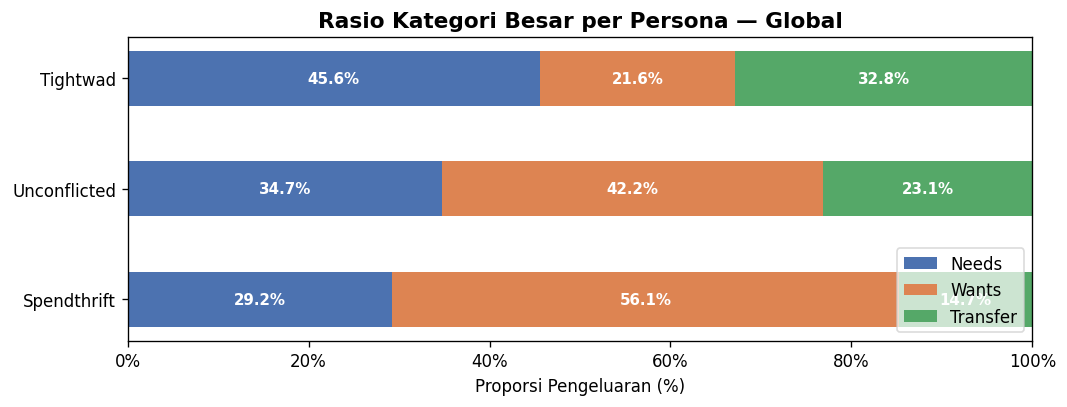

kategori_besar  Needs  Wants  Transfer
persona_dasar                         
Spendthrift      29.2   56.1      14.7
Unconflicted     34.7   42.2      23.1
Tightwad         45.6   21.6      32.8


In [25]:
# Merge debit dengan persona_dasar dari df_nas
df_persona = df_debit.merge(
    df_nas[['id_user', 'persona_dasar']],
    on='id_user', how='left'
)

# Agregasi: total nominal per persona × kategori_besar
ratio_global = (
    df_persona
    .groupby(['persona_dasar', 'kategori_besar'])['nominal']
    .sum()
    .reset_index()
)

# Hitung persentase dalam tiap persona (total = 100%)
ratio_global['pct'] = (
    ratio_global['nominal']
    / ratio_global.groupby('persona_dasar')['nominal'].transform('sum')
    * 100
)

# Pivot: baris = persona, kolom = kategori_besar
PERSONA_ORDER  = ['Spendthrift', 'Unconflicted', 'Tightwad']
KAT_BESAR_ORDER = ['Needs', 'Wants', 'Transfer']
COLORS          = {'Needs': '#4C72B0', 'Wants': '#DD8452', 'Transfer': '#55A868'}

pivot_global = (
    ratio_global
    .pivot(index='persona_dasar', columns='kategori_besar', values='pct')
    .reindex(index=PERSONA_ORDER, columns=KAT_BESAR_ORDER)
    .fillna(0)
)

# Plot stacked horizontal bar
fig, ax = plt.subplots(figsize=(9, 3.5))

left = [0] * len(PERSONA_ORDER)
for kat in KAT_BESAR_ORDER:
    vals = pivot_global[kat].values
    bars = ax.barh(PERSONA_ORDER, vals, left=left,
                   color=COLORS[kat], label=kat, height=0.5)
    for bar, val, lft in zip(bars, vals, left):
        if val >= 3:
            ax.text(
                lft + val / 2, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
    left = [l + v for l, v in zip(left, vals)]

ax.set_xlim(0, 100)
ax.set_xlabel('Proporsi Pengeluaran (%)')
ax.set_title('Rasio Kategori Besar per Persona — Global', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.7)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(pivot_global.round(1).to_string())

---
## 10. Rasio Kategori Besar per Persona per Segmen Pekerjaan

Breakdown yang sama dipecah per segmen demografi. Memverifikasi apakah pola Spendthrift→Wants berlaku konsisten di Mahasiswa, First Jobber, dan Profesional, atau ada perbedaan struktural antar segmen.

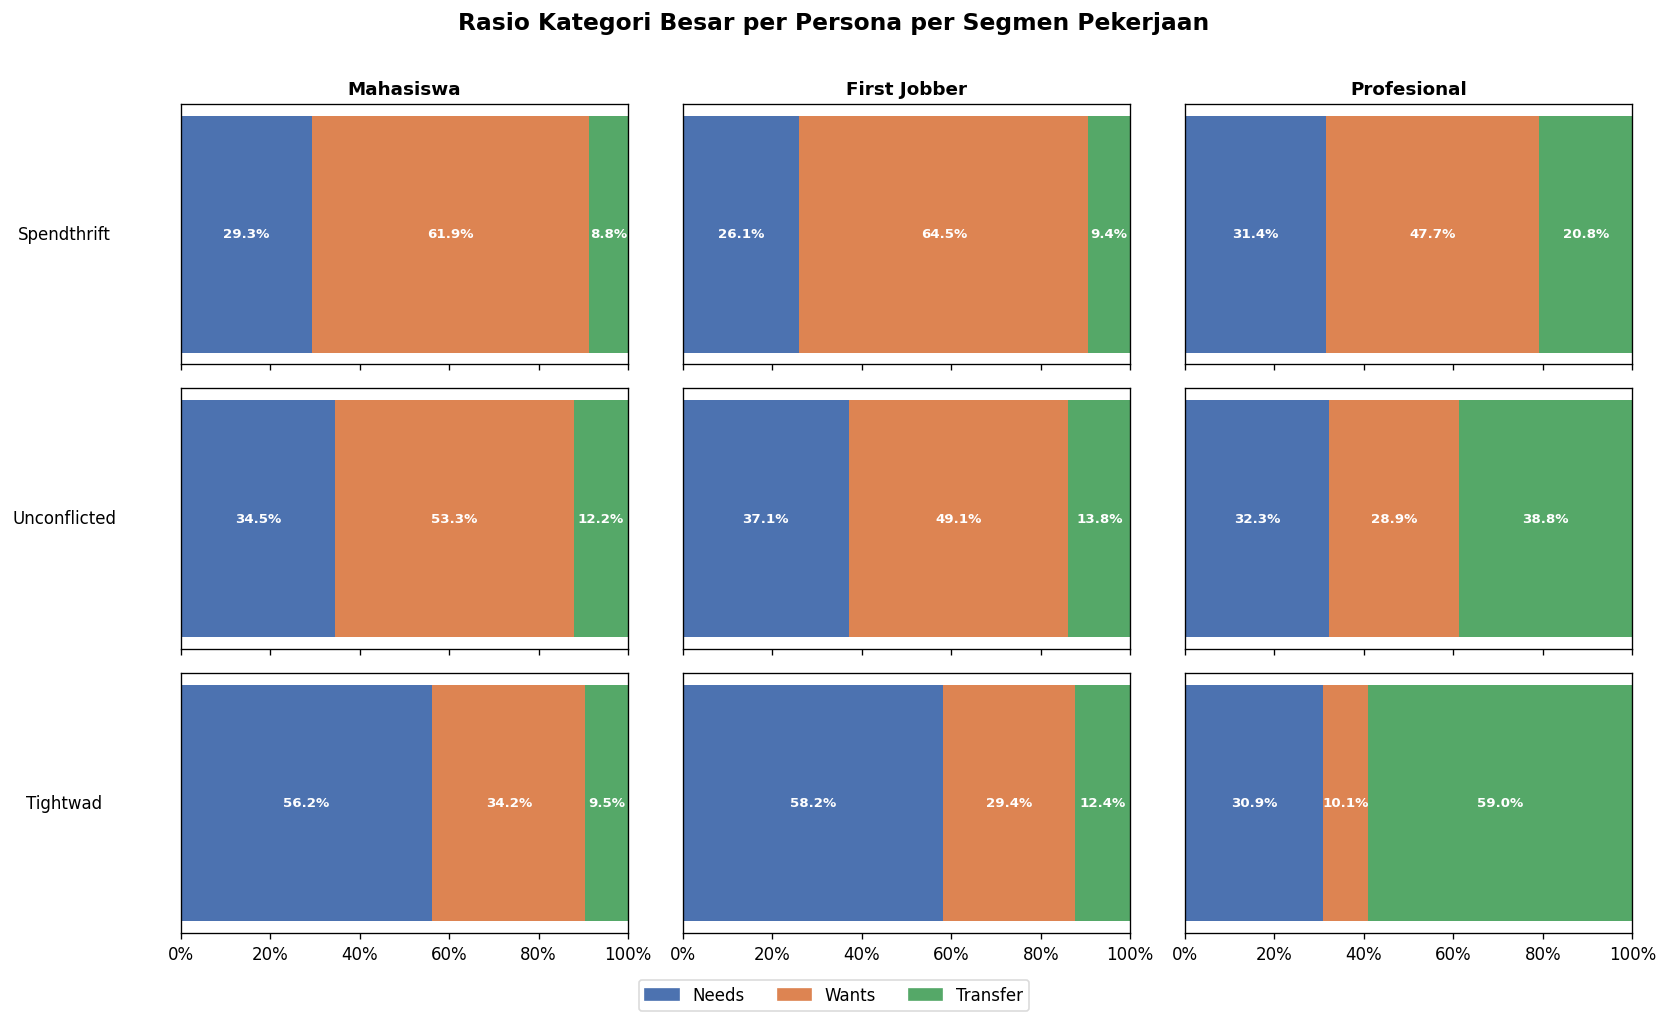

kategori_besar                  Needs  Wants  Transfer
segmen_demografi persona_dasar                        
Mahasiswa        Spendthrift     29.3   61.9       8.8
                 Unconflicted    34.5   53.3      12.2
                 Tightwad        56.2   34.2       9.5
First Jobber     Spendthrift     26.1   64.5       9.4
                 Unconflicted    37.1   49.1      13.8
                 Tightwad        58.2   29.4      12.4
Profesional      Spendthrift     31.4   47.7      20.8
                 Unconflicted    32.3   28.9      38.8
                 Tightwad        30.9   10.1      59.0


In [26]:
# Merge debit dengan persona + segmen
df_seg_persona = df_debit.merge(
    df_nas[['id_user', 'persona_dasar', 'segmen_demografi']],
    on='id_user', how='left'
)

# Agregasi: total nominal per segmen × persona × kategori_besar
ratio_seg = (
    df_seg_persona
    .groupby(['segmen_demografi', 'persona_dasar', 'kategori_besar'])['nominal']
    .sum()
    .reset_index()
)

# Persentase dalam tiap segmen × persona
ratio_seg['pct'] = (
    ratio_seg['nominal']
    / ratio_seg.groupby(['segmen_demografi', 'persona_dasar'])['nominal'].transform('sum')
    * 100
)

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']

# Grid 3 kolom (segmen) × 3 baris (persona)
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(14, 8),
    sharey=False, sharex=True
)
fig.suptitle(
    'Rasio Kategori Besar per Persona per Segmen Pekerjaan',
    fontsize=14, fontweight='bold', y=1.01
)

for col_idx, segmen in enumerate(SEGMEN_ORDER):
    for row_idx, persona in enumerate(PERSONA_ORDER):
        ax = axes[row_idx][col_idx]

        subset = ratio_seg[
            (ratio_seg['segmen_demografi'] == segmen) &
            (ratio_seg['persona_dasar']    == persona)
        ].set_index('kategori_besar')['pct'].reindex(KAT_BESAR_ORDER).fillna(0)

        left = 0
        for kat in KAT_BESAR_ORDER:
            val = subset[kat]
            ax.barh([0], [val], left=left,
                    color=COLORS[kat], label=kat if (row_idx == 0 and col_idx == 0) else '_',
                    height=0.5)
            if val >= 4:
                ax.text(
                    left + val / 2, 0,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold'
                )
            left += val

        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

        # Header kolom (segmen) — hanya baris pertama
        if row_idx == 0:
            ax.set_title(segmen, fontsize=11, fontweight='bold')

        # Label baris (persona) — hanya kolom pertama
        if col_idx == 0:
            ax.set_ylabel(persona, fontsize=10, rotation=0,
                          labelpad=70, va='center')

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color=COLORS[k]) for k in KAT_BESAR_ORDER
    ],
    labels=KAT_BESAR_ORDER,
    loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04),
    framealpha=0.7, fontsize=10
)

plt.tight_layout()
plt.show()

# Tabel ringkasan numerik
tbl = (
    ratio_seg
    .pivot_table(
        index=['segmen_demografi', 'persona_dasar'],
        columns='kategori_besar',
        values='pct'
    )
    .reindex(index=pd.MultiIndex.from_product([SEGMEN_ORDER, PERSONA_ORDER],
                                               names=['segmen_demografi', 'persona_dasar']),
             columns=KAT_BESAR_ORDER)
    .round(1)
)
print(tbl.to_string())